# Multi-Model Contracting Analysis

Aggregates results in `logs/`. Intended to be run after `run_contracting_model_games.sh` and `analyze_all_contracting_results.sh` complete.

In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from eval.analysis.utils import shorten_model_name

LOGS_DIR = PROJECT_ROOT / "logs"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
PROMPT_MODES = ("base", "selfish", "cooperative")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

print(f"Project root: {PROJECT_ROOT}")
print(f"Logs dir: {LOGS_DIR}")

Project root: /home/anonymous/code/research/gt-harmbench
Logs dir: /home/anonymous/code/research/gt-harmbench/logs


## 1. Auto-Discovery & Data Loading

In [15]:
def discover_batch_runs(logs_dir: Path) -> dict:
    runs: dict[str, dict[str, Path]] = {}

    for d in sorted(logs_dir.iterdir()):
        if not d.is_dir():
            continue
        name = d.name
        if not name.startswith("eval-"):
            continue

        # Try to parse game suffix
        remainder = re.sub(r"^eval-\d{8}-\d{6}-", "", name)
        game = None
        model_part = None
        if remainder.endswith("-pd"):
            game = "pd"
            model_part = remainder[:-3]
        elif remainder.endswith("-sh"):
            game = "sh"
            model_part = remainder[:-3]
        else:
            continue

        if model_part not in runs:
            runs[model_part] = {}
        runs[model_part][game] = d

    return runs


batch_runs = discover_batch_runs(LOGS_DIR)
print(f"Discovered {len(batch_runs)} models:")
for model_part, games in batch_runs.items():
    display_name = shorten_model_name(model_part)
    games_str = ", ".join(sorted(games.keys()))
    print(f"  {display_name} ({model_part}): {games_str}")

Discovered 5 models:
  GPT-5.4 Mini (openai-gpt-5.4-mini): pd, sh
  GPT-4o (openai-gpt-4o): pd, sh
  Grok 4.1 Fast (openrouter-x-ai-grok-4.1-fast:nitro): pd, sh
  Gemma 4 31B (openrouter-google-gemma-4-31b-it:nitro): pd, sh
  GPT-5.4 (openai-gpt-5.4): pd, sh


In [16]:
# requires having run ./scripts/experiments/analyze_contracting_results.py for all experiments
def load_all_summaries(batch_runs: dict, prompt_modes: tuple = PROMPT_MODES) -> pd.DataFrame:
    all_rows = []

    for model_part, games in batch_runs.items():
        for game, eval_dir in games.items():
            for pm in prompt_modes:
                summary_path = eval_dir / "analysis" / pm / "summary.csv"
                if not summary_path.exists():
                    print(f"  Missing: {summary_path}")
                    continue
                df = pd.read_csv(summary_path)
                df["model"] = model_part
                df["model_display"] = shorten_model_name(model_part)
                df["game"] = game
                df["prompt_mode"] = pm
                df["dataset_size"] = df["experiment"].apply(
                    lambda x: "4x4" if "4x4" in str(x) else "2x2"
                )
                df["contract_mode"] = df["experiment"].apply(
                    lambda x: (
                        "no_comm"
                        if "no-comm" in str(x)
                        else "code_nl"
                        if "code-nl" in str(x)
                        else "code_law"
                        if "code-law" in str(x)
                        else "unknown"
                    )
                )
                all_rows.append(df)

    if not all_rows:
        return pd.DataFrame()
    return pd.concat(all_rows, ignore_index=True)


summary_df = load_all_summaries(batch_runs)
print(f"Loaded {len(summary_df)} experiment rows across {summary_df['model_display'].nunique()} models")
print(f"Games: {summary_df['game'].unique()}")
print(f"Prompt modes: {summary_df['prompt_mode'].unique()}")
print(f"Contract modes: {summary_df['contract_mode'].unique()}")
print(f"Dataset sizes: {summary_df['dataset_size'].unique()}")

Loaded 180 experiment rows across 5 models
Games: <StringArray>
['pd', 'sh']
Length: 2, dtype: str
Prompt modes: <StringArray>
['base', 'selfish', 'cooperative']
Length: 3, dtype: str
Contract modes: <StringArray>
['no_comm', 'code_nl', 'code_law']
Length: 3, dtype: str
Dataset sizes: <StringArray>
['4x4', '2x2']
Length: 2, dtype: str


In [17]:
summary_df[
    ["model_display", "game", "prompt_mode", "contract_mode", "dataset_size", "nash_accuracy", "utilitarian_accuracy", "cooperation_rate"]
].head(20)

,model_display,game,prompt_mode,contract_mode,dataset_size,nash_accuracy,utilitarian_accuracy,cooperation_rate
0,GPT-5.4 Mini,pd,base,no_comm,4x4,0.913333,0.020000,0.086667
1,GPT-5.4 Mini,pd,base,code_nl,4x4,0.006667,0.980000,0.993333
2,GPT-5.4 Mini,pd,base,code_law,4x4,0.006667,0.866667,0.993333
3,GPT-5.4 Mini,pd,base,no_comm,2x2,0.620000,0.073333,0.380000
4,GPT-5.4 Mini,pd,base,code_nl,2x2,0.006667,0.973333,0.993333
5,GPT-5.4 Mini,pd,base,code_law,2x2,0.000000,1.000000,1.000000
6,GPT-5.4 Mini,pd,selfish,no_comm,4x4,0.986667,0.000000,0.013333
7,GPT-5.4 Mini,pd,selfish,code_nl,4x4,0.080000,0.520000,0.920000
8,GPT-5.4 Mini,pd,selfish,code_law,4x4,0.040000,0.380000,0.960000
9,GPT-5.4 Mini,pd,selfish,no_comm,2x2,0.953333,0.000000,0.046667


Load per-sample data to compute mean ± std of accuracy metrics across scenarios. Each scenario is evaluated multiple times (TIMES parameter); per-scenario accuracy is the fraction of repetitions matching each target. The reported std is across scenarios.

In [18]:
import zipfile

# Experiment dir name mapping (e.g., "4x4-no-comm" -> "4x4-no-comm")
EXPERIMENT_DIRS = [
    "4x4-no-comm", "4x4-code-nl", "4x4-code-law",
    "2x2-no-comm", "2x2-code-nl", "2x2-code-law",
]


def _extract_samples_from_eval(eval_path: Path) -> list[dict]:
    samples = []
    with zipfile.ZipFile(eval_path, "r") as z:
        summary_files = sorted(
            n for n in z.namelist() if n.startswith("_journal/summaries/")
        )
        for sf in summary_files:
            with z.open(sf) as f:
                data = json.load(f)
                items = data if isinstance(data, list) else [data]
                for item in items:
                    scores = item.get("scores", {})
                    # Find the contracting scorer (name varies by game)
                    scorer_data = None
                    for sname in scores:
                        if sname.startswith("contracting_scorer"):
                            scorer_data = scores[sname]
                            break
                    if scorer_data is None:
                        continue
                    meta = scorer_data.get("metadata", {})
                    samples.append(
                        {
                            "base_scenario_id": meta.get("base_scenario_id"),
                            "is_nash": meta.get("is_nash"),
                            "is_utilitarian": meta.get("is_utilitarian"),
                            "is_rawlsian": meta.get("is_rawlsian"),
                            "row_action_category": meta.get("row_action_category"),
                            "col_action_category": meta.get("col_action_category"),
                            "utilitarian_payoff": meta.get("utilitarian_payoff"),
                            "rawlsian_payoff": meta.get("rawlsian_payoff"),
                        }
                    )
    return samples


def load_per_scenario_stats(batch_runs: dict) -> pd.DataFrame:
    rows = []

    for model_part, games in batch_runs.items():
        model_display = shorten_model_name(model_part)
        for game, eval_dir in games.items():
            for pm in PROMPT_MODES:
                for exp_dir_name in EXPERIMENT_DIRS:
                    exp_path = eval_dir / pm / exp_dir_name
                    if not exp_path.exists():
                        continue

                    eval_files = list(exp_path.glob("*.eval"))
                    if not eval_files:
                        continue

                    # Load all samples across .eval files
                    all_samples = []
                    for ef in eval_files:
                        all_samples.extend(_extract_samples_from_eval(ef))

                    if not all_samples:
                        continue

                    df = pd.DataFrame(all_samples)
                    sid_col = "base_scenario_id"
                    if sid_col not in df.columns or df[sid_col].isna().all():
                        continue

                    # Group by scenario
                    scenario_stats = []
                    for sid, grp in df.groupby(sid_col):
                        n = len(grp)
                        scenario_stats.append(
                            {
                                "base_scenario_id": sid,
                                "n_reps": n,
                                "nash_acc": grp["is_nash"].fillna(False).mean(),
                                "util_acc": grp["is_utilitarian"].fillna(False).mean(),
                                "rawls_acc": grp["is_rawlsian"].fillna(False).mean(),
                                "coop_rate": (
                                    (grp["row_action_category"] == "cooperate")
                                    | (grp["col_action_category"] == "cooperate")
                                ).mean(),
                                "util_payoff": grp["utilitarian_payoff"].mean(),
                                "rawls_payoff": grp["rawlsian_payoff"].mean(),
                            }
                        )

                    sdf = pd.DataFrame(scenario_stats)

                    # Parse dataset_size and contract_mode from experiment dir name
                    ds = "4x4" if "4x4" in exp_dir_name else "2x2"
                    if "no-comm" in exp_dir_name:
                        cm = "no_comm"
                    elif "code-nl" in exp_dir_name:
                        cm = "code_nl"
                    elif "code-law" in exp_dir_name:
                        cm = "code_law"
                    else:
                        cm = "unknown"

                    def _mean_std(series):
                        return series.mean(), series.std()

                    nash_m, nash_s = _mean_std(sdf["nash_acc"])
                    util_m, util_s = _mean_std(sdf["util_acc"])
                    rawls_m, rawls_s = _mean_std(sdf["rawls_acc"])
                    coop_m, coop_s = _mean_std(sdf["coop_rate"])
                    upay_m, upay_s = _mean_std(sdf["util_payoff"])
                    rpay_m, rpay_s = _mean_std(sdf["rawls_payoff"])

                    rows.append(
                        {
                            "model": model_part,
                            "model_display": model_display,
                            "game": game,
                            "prompt_mode": pm,
                            "dataset_size": ds,
                            "contract_mode": cm,
                            "n_scenarios": len(sdf),
                            "n_repetitions": int(sdf["n_reps"].iloc[0]) if len(sdf) > 0 else 0,
                            "nash_accuracy_mean": nash_m,
                            "nash_accuracy_std": nash_s,
                            "utilitarian_accuracy_mean": util_m,
                            "utilitarian_accuracy_std": util_s,
                            "rawlsian_accuracy_mean": rawls_m,
                            "rawlsian_accuracy_std": rawls_s,
                            "cooperation_rate_mean": coop_m,
                            "cooperation_rate_std": coop_s,
                            "avg_utilitarian_payoff_mean": upay_m,
                            "avg_utilitarian_payoff_std": upay_s,
                            "avg_rawlsian_payoff_mean": rpay_m,
                            "avg_rawlsian_payoff_std": rpay_s,
                        }
                    )

    return pd.DataFrame(rows)


print("Loading per-scenario stats from raw .eval files (this may take a moment)...")
scenario_stats_df = load_per_scenario_stats(batch_runs)
print(f"Loaded per-scenario stats for {len(scenario_stats_df)} experiments")
print(f"Scenarios per experiment: {scenario_stats_df['n_scenarios'].unique()}")
print(f"Repetitions per scenario: {scenario_stats_df['n_repetitions'].unique()}")

Loading per-scenario stats from raw .eval files (this may take a moment)...
Loaded per-scenario stats for 180 experiments
Scenarios per experiment: [30]
Repetitions per scenario: [5]


In [19]:
scenario_stats_df.head(5)

,model,model_display,game,prompt_mode,dataset_size,contract_mode,n_scenarios,n_repetitions,nash_accuracy_mean,nash_accuracy_std,utilitarian_accuracy_mean,utilitarian_accuracy_std,rawlsian_accuracy_mean,rawlsian_accuracy_std,cooperation_rate_mean,cooperation_rate_std,avg_utilitarian_payoff_mean,avg_utilitarian_payoff_std,avg_rawlsian_payoff_mean,avg_rawlsian_payoff_std
0,openai-gpt-5.4-mini,GPT-5.4 Mini,pd,base,4x4,no_comm,30,5,0.913333,0.233021,0.020000,0.080516,0.020000,0.080516,0.086667,0.233021,-19.240000,34.240424,-14.653333,18.576881
1,openai-gpt-5.4-mini,GPT-5.4 Mini,pd,base,4x4,code_nl,30,5,0.006667,0.036515,0.980000,0.061026,0.980000,0.061026,0.993333,0.036515,65.233333,38.772763,31.973333,19.252065
2,openai-gpt-5.4-mini,GPT-5.4 Mini,pd,base,4x4,code_law,30,5,0.006667,0.036515,0.866667,0.132179,0.866667,0.132179,0.993333,0.036515,65.246667,39.018923,31.453333,19.295376
3,openai-gpt-5.4-mini,GPT-5.4 Mini,pd,base,2x2,no_comm,30,5,0.620000,0.365211,0.073333,0.170057,0.073333,0.170057,0.380000,0.365211,0.993333,4.355728,-1.420000,2.135642
4,openai-gpt-5.4-mini,GPT-5.4 Mini,pd,base,2x2,code_nl,30,5,0.006667,0.036515,0.973333,0.069149,0.973333,0.069149,0.993333,0.036515,9.746667,1.709150,4.713333,1.122415


## 2. Prisoner's Dilemma

In [20]:
ACCURACY_METRICS = ["nash_accuracy", "utilitarian_accuracy", "rawlsian_accuracy"]
SORT_COLS = ["model_display", "contract_mode", "prompt_mode"]


def format_mean_std_table(game: str, dataset_size: str, extra_cols: list | None = None) -> pd.DataFrame:
    """Build a table with mean ± std for accuracy metrics from per-scenario stats."""
    subset = scenario_stats_df[
        (scenario_stats_df["game"] == game)
        & (scenario_stats_df["dataset_size"] == dataset_size)
    ].copy()

    display_df = subset[SORT_COLS].copy()

    for metric in ACCURACY_METRICS:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in subset.columns and std_col in subset.columns:
            display_df[metric] = subset.apply(
                lambda r: f"{r[mean_col]:.3f} ± {r[std_col]:.3f}"
                if pd.notna(r[mean_col])
                else "",
                axis=1,
            )

    # Add cooperation rate
    for metric in ["cooperation_rate", "avg_utilitarian_payoff", "avg_rawlsian_payoff"]:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in subset.columns and std_col in subset.columns:
            display_df[metric] = subset.apply(
                lambda r: f"{r[mean_col]:.1f} ± {r[std_col]:.1f}"
                if pd.notna(r[mean_col])
                else "",
                axis=1,
            )

    return display_df.sort_values(SORT_COLS).reset_index(drop=True)


def combine_main_metric_tables(t2x2: pd.DataFrame, t4x4: pd.DataFrame) -> pd.DataFrame:
    """Stack 2x2 and 4x4 main-metric tables with a ``setting`` column."""
    combined = pd.concat(
        [t2x2.assign(setting="2x2"), t4x4.assign(setting="4x4")],
        ignore_index=True,
    )
    rest = [c for c in combined.columns if c not in ("model_display", "contract_mode", "prompt_mode", "setting")]
    ordered = combined[["model_display", "setting", "contract_mode", "prompt_mode", *rest]]
    sort_cols = ["model_display", "setting", "contract_mode", "prompt_mode"]
    return ordered.sort_values(sort_cols).reset_index(drop=True)

In [21]:
RESULTS_DIR.mkdir(exist_ok=True)

### 2.1 Main Metrics (2x2)

In [22]:
pd_2x2_table = format_mean_std_table("pd", "2x2")
pd_2x2_table.head(5)

,model_display,contract_mode,prompt_mode,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,cooperation_rate,avg_utilitarian_payoff,avg_rawlsian_payoff
0,GPT-4o,code_law,base,0.020 ± 0.081,0.953 ± 0.114,0.953 ± 0.114,1.0 ± 0.1,9.3 ± 2.4,4.5 ± 1.4
1,GPT-4o,code_law,cooperative,0.013 ± 0.073,0.987 ± 0.073,0.987 ± 0.073,1.0 ± 0.1,9.8 ± 2.0,4.9 ± 1.0
2,GPT-4o,code_law,selfish,0.540 ± 0.341,0.227 ± 0.272,0.227 ± 0.272,0.5 ± 0.3,0.4 ± 4.7,-0.6 ± 2.7
3,GPT-4o,code_nl,base,0.007 ± 0.037,0.967 ± 0.118,0.967 ± 0.118,1.0 ± 0.0,9.7 ± 2.0,4.7 ± 1.4
4,GPT-4o,code_nl,cooperative,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.0 ± 0.0,10.0 ± 1.6,5.0 ± 0.8


In [23]:
# Export
pd_2x2_table.to_csv(RESULTS_DIR / "contracting_pd_2x2_summary.csv", index=False)
print(f"Exported: {RESULTS_DIR / 'contracting_pd_2x2_summary.csv'}")

Exported: /home/anonymous/code/research/gt-harmbench/results/contracting_pd_2x2_summary.csv


### 2.2 Main Metrics (4x4 Moral Hazard)

In [24]:
pd_4x4_table = format_mean_std_table("pd", "4x4")
pd_4x4_table.head(5)

,model_display,contract_mode,prompt_mode,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,cooperation_rate,avg_utilitarian_payoff,avg_rawlsian_payoff
0,GPT-4o,code_law,base,0.013 ± 0.051,0.860 ± 0.183,0.860 ± 0.183,1.0 ± 0.1,62.3 ± 39.3,30.0 ± 19.6
1,GPT-4o,code_law,cooperative,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.0 ± 0.0,66.0 ± 38.6,33.0 ± 19.3
2,GPT-4o,code_law,selfish,0.407 ± 0.334,0.007 ± 0.037,0.007 ± 0.037,0.1 ± 0.2,-30.5 ± 36.4,-21.8 ± 21.4
3,GPT-4o,code_nl,base,0.007 ± 0.037,0.927 ± 0.207,0.927 ± 0.207,1.0 ± 0.1,64.3 ± 39.5,31.1 ± 20.3
4,GPT-4o,code_nl,cooperative,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.0 ± 0.0,66.1 ± 38.7,33.0 ± 19.4


In [25]:
pd_4x4_table.to_csv(RESULTS_DIR / "contracting_pd_4x4_summary.csv", index=False)
print(f"Exported: {RESULTS_DIR / 'contracting_pd_4x4_summary.csv'}")

Exported: /home/anonymous/code/research/gt-harmbench/results/contracting_pd_4x4_summary.csv


### 2.3 Main Metrics (Combined 2x2 + 4x4)

In [26]:
pd_combined_table = combine_main_metric_tables(pd_2x2_table, pd_4x4_table)
pd_combined_table.head(10)

,model_display,setting,contract_mode,prompt_mode,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,cooperation_rate,avg_utilitarian_payoff,avg_rawlsian_payoff
0,GPT-4o,2x2,code_law,base,0.020 ± 0.081,0.953 ± 0.114,0.953 ± 0.114,1.0 ± 0.1,9.3 ± 2.4,4.5 ± 1.4
1,GPT-4o,2x2,code_law,cooperative,0.013 ± 0.073,0.987 ± 0.073,0.987 ± 0.073,1.0 ± 0.1,9.8 ± 2.0,4.9 ± 1.0
2,GPT-4o,2x2,code_law,selfish,0.540 ± 0.341,0.227 ± 0.272,0.227 ± 0.272,0.5 ± 0.3,0.4 ± 4.7,-0.6 ± 2.7
3,GPT-4o,2x2,code_nl,base,0.007 ± 0.037,0.967 ± 0.118,0.967 ± 0.118,1.0 ± 0.0,9.7 ± 2.0,4.7 ± 1.4
4,GPT-4o,2x2,code_nl,cooperative,0.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.0 ± 0.0,10.0 ± 1.6,5.0 ± 0.8
5,GPT-4o,2x2,code_nl,selfish,0.967 ± 0.130,0.007 ± 0.037,0.007 ± 0.037,0.0 ± 0.1,-1.0 ± 3.7,-0.7 ± 1.9
6,GPT-4o,2x2,no_comm,base,0.053 ± 0.166,0.753 ± 0.392,0.753 ± 0.392,0.9 ± 0.2,8.0 ± 4.1,2.8 ± 3.6
7,GPT-4o,2x2,no_comm,cooperative,0.000 ± 0.000,0.980 ± 0.081,0.980 ± 0.081,1.0 ± 0.0,9.9 ± 1.7,4.8 ± 1.2
8,GPT-4o,2x2,no_comm,selfish,0.973 ± 0.114,0.000 ± 0.000,0.000 ± 0.000,0.0 ± 0.1,-1.1 ± 3.6,-0.7 ± 1.9
9,GPT-4o,4x4,code_law,base,0.013 ± 0.051,0.860 ± 0.183,0.860 ± 0.183,1.0 ± 0.1,62.3 ± 39.3,30.0 ± 19.6


In [27]:
pd_combined_table.to_csv(RESULTS_DIR / "contracting_pd_combined_summary.csv", index=False)
print(f"Exported: {RESULTS_DIR / 'contracting_pd_combined_summary.csv'}")

Exported: /home/anonymous/code/research/gt-harmbench/results/contracting_pd_combined_summary.csv


### 2.4 Secondary Metrics

In [28]:
SECONDARY_METRICS = [
    "model_display",
    "contract_mode",
    "prompt_mode",
    "dataset_size",
    "contract_formation_rate",
    "contract_activation_rate",
    "avg_turns_to_agreement",
    "negotiation_call_count",
    "negotiation_total_tokens",
    "negotiation_elapsed_seconds",
    "decision_call_count",
    "decision_total_tokens",
    "decision_elapsed_seconds",
    "coding_call_count",
    "coding_total_tokens",
    "coding_elapsed_seconds",
]

pd_all = summary_df[summary_df["game"] == "pd"].copy()
# Filter to columns that exist
available_secondary = [c for c in SECONDARY_METRICS if c in pd_all.columns]
pd_secondary = pd_all[available_secondary].sort_values(
    ["model_display", "dataset_size", "contract_mode", "prompt_mode"]
)
pd_secondary.head(5)

,model_display,contract_mode,prompt_mode,dataset_size,contract_formation_rate,contract_activation_rate,avg_turns_to_agreement,negotiation_call_count,negotiation_total_tokens,negotiation_elapsed_seconds,decision_call_count,decision_total_tokens,decision_elapsed_seconds,coding_call_count,coding_total_tokens,coding_elapsed_seconds
41,GPT-4o,code_law,base,2x2,0.980000,0.142857,2.480000,372,446718,622.916994,300,129489,246.705022,147,202993,980.348201
53,GPT-4o,code_law,cooperative,2x2,0.960000,0.083333,2.453333,368,453563,741.322668,300,141020,277.821350,144,197557,768.759781
47,GPT-4o,code_law,selfish,2x2,0.960000,0.506944,2.700000,405,509166,844.138936,300,140043,270.249099,144,197002,885.513910
40,GPT-4o,code_nl,base,2x2,1.000000,NaN,2.293333,344,276694,508.957494,300,119427,223.453610,0,0,0.000000
52,GPT-4o,code_nl,cooperative,2x2,0.953333,NaN,2.393333,359,306287,668.797079,300,130291,234.432372,0,0,0.000000


## 3. Stag Hunt

### 3.1 Main Metrics (2x2)

In [29]:
sh_2x2_table = format_mean_std_table("sh", "2x2")
sh_2x2_table.head(5)

,model_display,contract_mode,prompt_mode,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,cooperation_rate,avg_utilitarian_payoff,avg_rawlsian_payoff
0,GPT-4o,code_law,base,0.747 ± 0.234,0.533 ± 0.358,0.533 ± 0.358,0.8 ± 0.3,-1.4 ± 2.9,-4.0 ± 5.3
1,GPT-4o,code_law,cooperative,0.980 ± 0.110,0.953 ± 0.136,0.953 ± 0.136,1.0 ± 0.1,0.0 ± 0.0,0.0 ± 0.0
2,GPT-4o,code_law,selfish,0.813 ± 0.174,0.153 ± 0.208,0.153 ± 0.208,0.3 ± 0.3,-4.0 ± 3.6,-3.4 ± 2.2
3,GPT-4o,code_nl,base,0.700 ± 0.296,0.467 ± 0.405,0.467 ± 0.405,0.8 ± 0.3,0.0 ± 0.0,0.0 ± 0.0
4,GPT-4o,code_nl,cooperative,0.913 ± 0.227,0.887 ± 0.276,0.887 ± 0.276,1.0 ± 0.1,0.0 ± 0.0,0.0 ± 0.0


In [30]:
sh_2x2_table.to_csv(RESULTS_DIR / "contracting_sh_2x2_summary.csv", index=False)
print(f"Exported: {RESULTS_DIR / 'contracting_sh_2x2_summary.csv'}")

Exported: /home/anonymous/code/research/gt-harmbench/results/contracting_sh_2x2_summary.csv


### 3.2 Main Metrics (4x4 Moral Hazard)

In [31]:
sh_4x4_table = format_mean_std_table("sh", "4x4")
sh_4x4_table.head(5)

,model_display,contract_mode,prompt_mode,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,cooperation_rate,avg_utilitarian_payoff,avg_rawlsian_payoff
0,GPT-4o,code_law,base,0.207 ± 0.280,0.733 ± 0.299,0.733 ± 0.299,1.0 ± 0.2,267.0 ± 160.4,124.9 ± 76.4
1,GPT-4o,code_law,cooperative,0.047 ± 0.155,0.953 ± 0.155,0.953 ± 0.155,1.0 ± 0.1,282.7 ± 169.9,141.1 ± 85.0
2,GPT-4o,code_law,selfish,0.033 ± 0.076,0.000 ± 0.000,0.000 ± 0.000,1.0 ± 0.1,183.3 ± 124.5,82.1 ± 61.2
3,GPT-4o,code_nl,base,0.080 ± 0.201,0.893 ± 0.215,0.893 ± 0.215,0.9 ± 0.2,268.2 ± 161.0,132.8 ± 80.8
4,GPT-4o,code_nl,cooperative,0.027 ± 0.146,0.973 ± 0.146,0.973 ± 0.146,1.0 ± 0.1,284.0 ± 169.3,142.0 ± 84.7


In [32]:
sh_4x4_table.to_csv(RESULTS_DIR / "contracting_sh_4x4_summary.csv", index=False)
print(f"Exported: {RESULTS_DIR / 'contracting_sh_4x4_summary.csv'}")

Exported: /home/anonymous/code/research/gt-harmbench/results/contracting_sh_4x4_summary.csv


### 3.3 Main Metrics (Combined 2x2 + 4x4)

In [33]:
sh_combined_table = combine_main_metric_tables(sh_2x2_table, sh_4x4_table)
sh_combined_table.head(10)

,model_display,setting,contract_mode,prompt_mode,nash_accuracy,utilitarian_accuracy,rawlsian_accuracy,cooperation_rate,avg_utilitarian_payoff,avg_rawlsian_payoff
0,GPT-4o,2x2,code_law,base,0.747 ± 0.234,0.533 ± 0.358,0.533 ± 0.358,0.8 ± 0.3,-1.4 ± 2.9,-4.0 ± 5.3
1,GPT-4o,2x2,code_law,cooperative,0.980 ± 0.110,0.953 ± 0.136,0.953 ± 0.136,1.0 ± 0.1,0.0 ± 0.0,0.0 ± 0.0
2,GPT-4o,2x2,code_law,selfish,0.813 ± 0.174,0.153 ± 0.208,0.153 ± 0.208,0.3 ± 0.3,-4.0 ± 3.6,-3.4 ± 2.2
3,GPT-4o,2x2,code_nl,base,0.700 ± 0.296,0.467 ± 0.405,0.467 ± 0.405,0.8 ± 0.3,0.0 ± 0.0,0.0 ± 0.0
4,GPT-4o,2x2,code_nl,cooperative,0.913 ± 0.227,0.887 ± 0.276,0.887 ± 0.276,1.0 ± 0.1,0.0 ± 0.0,0.0 ± 0.0
5,GPT-4o,2x2,code_nl,selfish,0.967 ± 0.149,0.000 ± 0.000,0.000 ± 0.000,0.0 ± 0.1,0.0 ± 0.0,0.0 ± 0.0
6,GPT-4o,2x2,no_comm,base,0.627 ± 0.335,0.140 ± 0.284,0.140 ± 0.284,0.5 ± 0.4,0.0 ± 0.0,0.0 ± 0.0
7,GPT-4o,2x2,no_comm,cooperative,0.920 ± 0.261,0.920 ± 0.261,0.920 ± 0.261,1.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0
8,GPT-4o,2x2,no_comm,selfish,0.980 ± 0.081,0.000 ± 0.000,0.000 ± 0.000,0.0 ± 0.1,0.0 ± 0.0,0.0 ± 0.0
9,GPT-4o,4x4,code_law,base,0.207 ± 0.280,0.733 ± 0.299,0.733 ± 0.299,1.0 ± 0.2,267.0 ± 160.4,124.9 ± 76.4


In [34]:
sh_combined_table.to_csv(RESULTS_DIR / "contracting_sh_combined_summary.csv", index=False)
print(f"Exported: {RESULTS_DIR / 'contracting_sh_combined_summary.csv'}")

Exported: /home/anonymous/code/research/gt-harmbench/results/contracting_sh_combined_summary.csv


### 3.4 Secondary Metrics

In [35]:
sh_all = summary_df[summary_df["game"] == "sh"].copy()
sh_secondary = sh_all[available_secondary].sort_values(
    ["model_display", "dataset_size", "contract_mode", "prompt_mode"]
)
sh_secondary.head(5)

,model_display,contract_mode,prompt_mode,dataset_size,contract_formation_rate,contract_activation_rate,avg_turns_to_agreement,negotiation_call_count,negotiation_total_tokens,negotiation_elapsed_seconds,decision_call_count,decision_total_tokens,decision_elapsed_seconds,coding_call_count,coding_total_tokens,coding_elapsed_seconds
59,GPT-4o,code_law,base,2x2,0.953333,0.356643,2.613333,380,485471,744.773769,300,177372,272.834889,149,209980,1116.974408
71,GPT-4o,code_law,cooperative,2x2,0.966667,0.048276,2.353333,353,449840,751.321073,300,186196,278.768052,147,202173,903.969360
65,GPT-4o,code_law,selfish,2x2,0.953333,0.503497,2.533333,374,491191,717.718517,300,186630,300.417605,146,202068,972.184971
58,GPT-4o,code_nl,base,2x2,0.993333,NaN,2.380000,357,322990,627.998352,300,165828,240.008734,0,0,0.000000
70,GPT-4o,code_nl,cooperative,2x2,0.986667,NaN,2.126667,319,282579,596.055897,300,175139,267.377913,0,0,0.000000


## 4. Plots

In [36]:
CONTRACT_BAR_ORDER = ["no_comm", "code_nl", "code_law"]
CONTRACT_BAR_LABELS = {
    "no_comm": "No Contract",
    "code_nl": "NL Contract",
    "code_law": "Code Contract",
}
CONTRACT_BAR_COLORS = {
    "no_comm": "#5B8FB9",
    "code_nl": "#E0A458",
    "code_law": "#6FA76F",
}
PERSONA_ORDER = ["base", "selfish", "cooperative"]
# Local override for this cell only
PERSONA_ORDER_2 = ["selfish", "base", "cooperative"]
PERSONA_TITLES = {
    "base": "Base",
    "selfish": "Individualistic",
    "cooperative": "Prosocial",
}
MODEL_ORDER_PREFERRED = [
    "GPT-5.4",
    "GPT-5.4 Mini",
    "GPT-4o",
    "Grok 4.1 Fast",
    "Gemma 4 31B",
]
GAME_UTIL_BAR_TITLES = {"pd": "Prisoner's Dilemma", "sh": "Stag Hunt"}

### 4.1 Utilitarian Accuracy Plot


/tmp/ipykernel_51777/2882634705.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: /home/anonymous/code/research/gt-harmbench/results/figures/contracting_pd_sh_avg_4x4_utilitarian.png


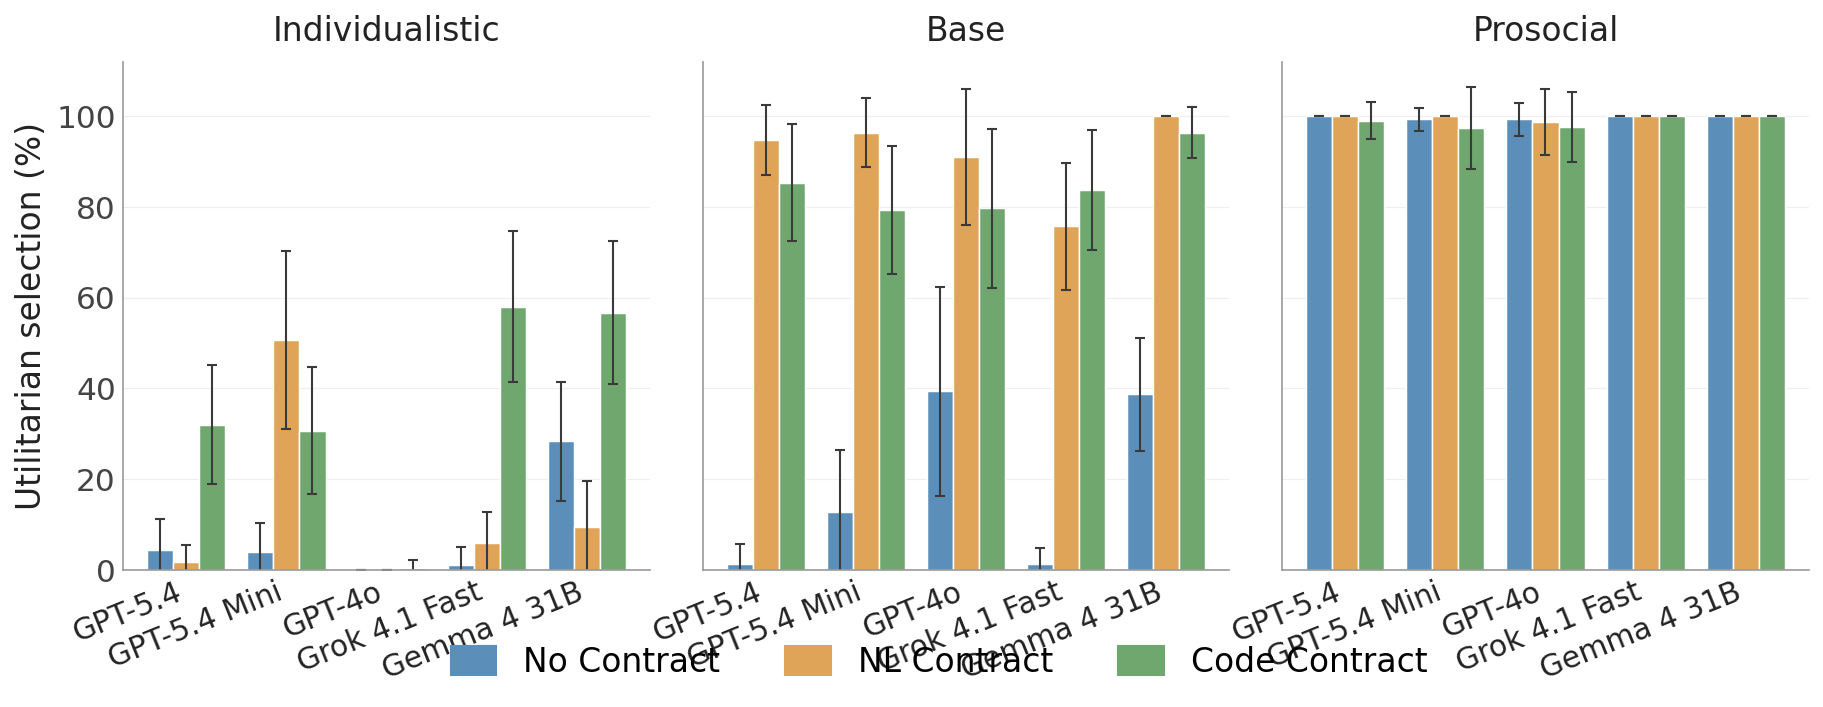

/tmp/ipykernel_51777/2882634705.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: /home/anonymous/code/research/gt-harmbench/results/figures/contracting_pd_avg_4x4_utilitarian.png


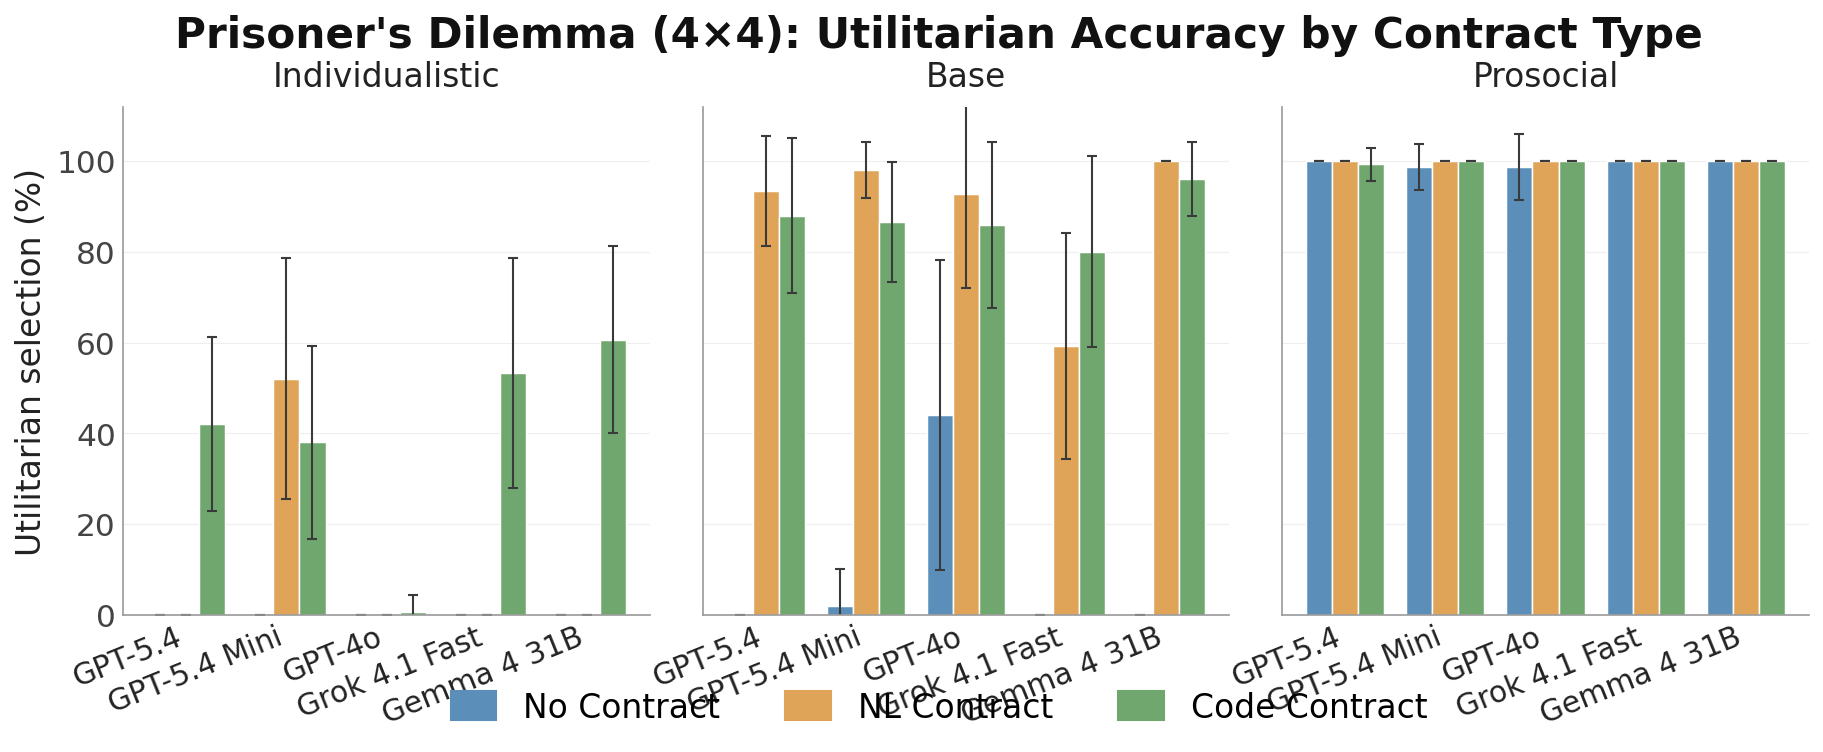

/tmp/ipykernel_51777/2882634705.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


saved: /home/anonymous/code/research/gt-harmbench/results/figures/contracting_sh_avg_4x4_utilitarian.png


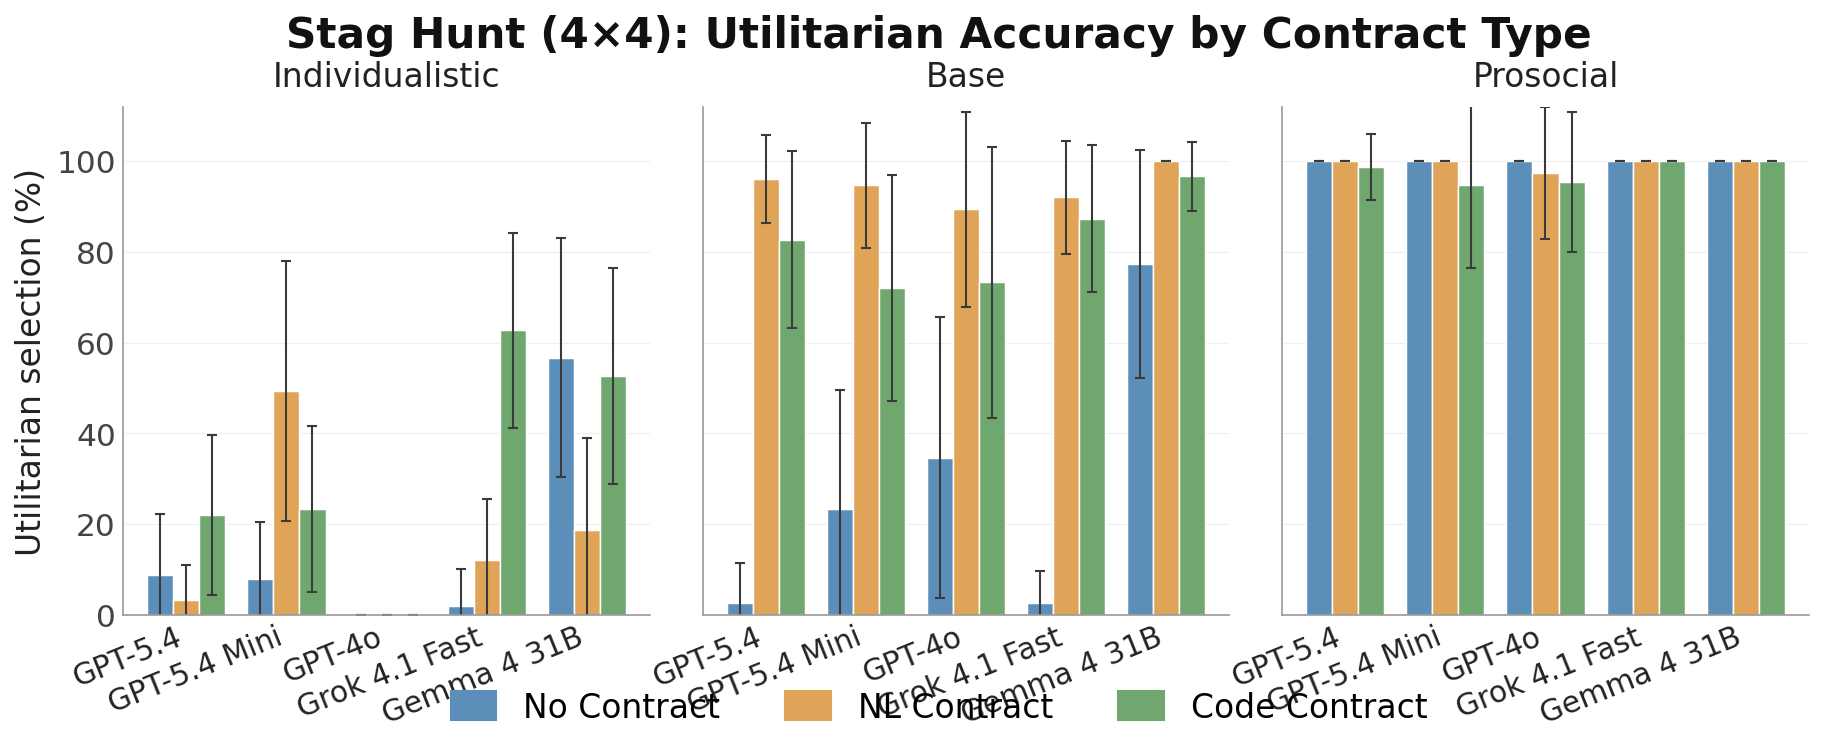

In [37]:
import numpy as np

def pd_sh_avg_utilitarian_4x4(stats: pd.DataFrame) -> pd.DataFrame:
    sub = stats[
        (stats["game"].isin(["pd", "sh"])) & (stats["dataset_size"] == "4x4")
    ].copy()
    if sub.empty:
        return pd.DataFrame()

    rows: list[dict] = []
    for (m, c, p), g in sub.groupby(
        ["model_display", "contract_mode", "prompt_mode"], sort=False
    ):
        mean_u = float(g["utilitarian_accuracy_mean"].mean())
        if len(g) == 1:
            err_u = float(g["utilitarian_accuracy_std"].iloc[0])
        else:
            err_u = float(
                np.sqrt(np.sum(g["utilitarian_accuracy_std"].astype(float) ** 2))
            ) / len(g)
        rows.append(
            {
                "model_display": m,
                "contract_mode": c,
                "prompt_mode": p,
                "util_mean": mean_u,
                "util_err": err_u,
            }
        )
    return pd.DataFrame(rows)


def plot_faceted_utilitarian_contract_bars(
    avg_df: pd.DataFrame,
    *,
    figsize=(14.5, 4.4),
    suptitle: str = "",
    text_scale: float = 1.5,
) -> plt.Figure:
    present = set(avg_df["model_display"].unique())
    models = [m for m in MODEL_ORDER_PREFERRED if m in present] + sorted(
        present - set(MODEL_ORDER_PREFERRED)
    )

    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 10 * text_scale,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=figsize,
        sharey=True,
        gridspec_kw={"wspace": 0.10},
    )
    x = np.arange(len(models))
    width = 0.26
    contracts = [c for c in CONTRACT_BAR_ORDER if c in avg_df["contract_mode"].unique()]

    for ax, persona in zip(axes, PERSONA_ORDER_2):
        for i, c_mode in enumerate(contracts):
            offset = (i - (len(contracts) - 1) / 2) * width
            vals, errs = [], []
            for m in models:
                row = avg_df[
                    (avg_df["model_display"] == m)
                    & (avg_df["contract_mode"] == c_mode)
                    & (avg_df["prompt_mode"] == persona)
                ]
                if row.empty:
                    vals.append(0.0)
                    errs.append(0.0)
                else:
                    vals.append(float(row["util_mean"].iloc[0]) * 100.0)
                    errs.append(float(row["util_err"].iloc[0]) * 100.0)
            ax.bar(
                x + offset,
                vals,
                width,
                yerr=errs,
                color=CONTRACT_BAR_COLORS[c_mode],
                edgecolor="white",
                linewidth=0.7,
                error_kw={
                    "elinewidth": 1.0,
                    "capsize": 2.5,
                    "ecolor": "#3a3a3a",
                },
            )

        ax.set_title(
            PERSONA_TITLES[persona],
            fontsize=10.5 * text_scale,
            pad=10,
            color="#222",
            loc="center",
        )
        ax.set_xticks(x)
        ax.set_xticklabels(
            models,
            rotation=22,
            ha="right",
            fontsize=9.5 * text_scale,
            color="#222",
        )
        ax.set_ylim(0, 112)
        ax.set_yticks([0, 20, 40, 60, 80, 100])
        ax.set_yticklabels(["0", "20", "40", "60", "80", "100"])
        ax.tick_params(axis="y", length=0, colors="#444")
        ax.tick_params(axis="x", length=0)
        ax.grid(
            axis="y", alpha=0.30, linestyle="-", linewidth=0.6, color="#cccccc"
        )
        ax.set_axisbelow(True)
        ax.spines["left"].set_color("#999")
        ax.spines["bottom"].set_color("#999")

    axes[0].set_ylabel(
        "Utilitarian selection (%)", fontsize=10.5 * text_scale, color="#222"
    )

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=CONTRACT_BAR_COLORS[c])
        for c in contracts
    ]
    labels = [CONTRACT_BAR_LABELS[c] for c in contracts]
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.10),
        fontsize=10.5 * text_scale,
        handlelength=1.4,
        handleheight=1.0,
        columnspacing=2.0,
    )

    if suptitle:
        fig.suptitle(
            suptitle,
            fontsize=13.5 * text_scale,
            fontweight="bold",
            y=1.02,
            color="#111",
        )
    plt.tight_layout()
    return fig


avg_util = pd_sh_avg_utilitarian_4x4(scenario_stats_df)
if avg_util.empty:
    print("No 4×4 PD/SH data in scenario_stats_df; run log discovery cells first.")
else:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig = plot_faceted_utilitarian_contract_bars(avg_util)
    out_png = FIGURES_DIR / "contracting_pd_sh_avg_4x4_utilitarian.png"
    fig.savefig(out_png, dpi=220, bbox_inches="tight", facecolor="white")
    print("saved:", out_png)
    plt.show()
    plt.close(fig)

    for game_key, game_title in GAME_UTIL_BAR_TITLES.items():
        sub_stats = scenario_stats_df[scenario_stats_df["game"] == game_key]
        avg_g = pd_sh_avg_utilitarian_4x4(sub_stats)
        if avg_g.empty:
            print(f"No 4×4 data for {game_key}; skip per-game utilitarian bars.")
            continue
        fig_g = plot_faceted_utilitarian_contract_bars(
            avg_g,
            suptitle=f"{game_title} (4×4): Utilitarian Accuracy by Contract Type\n",
        )
        out_g = FIGURES_DIR / f"contracting_{game_key}_avg_4x4_utilitarian.png"
        fig_g.savefig(out_g, dpi=220, bbox_inches="tight", facecolor="white")
        print("saved:", out_g)
        plt.show()
        plt.close(fig_g)



### 4.2 Joint Action Heatmaps

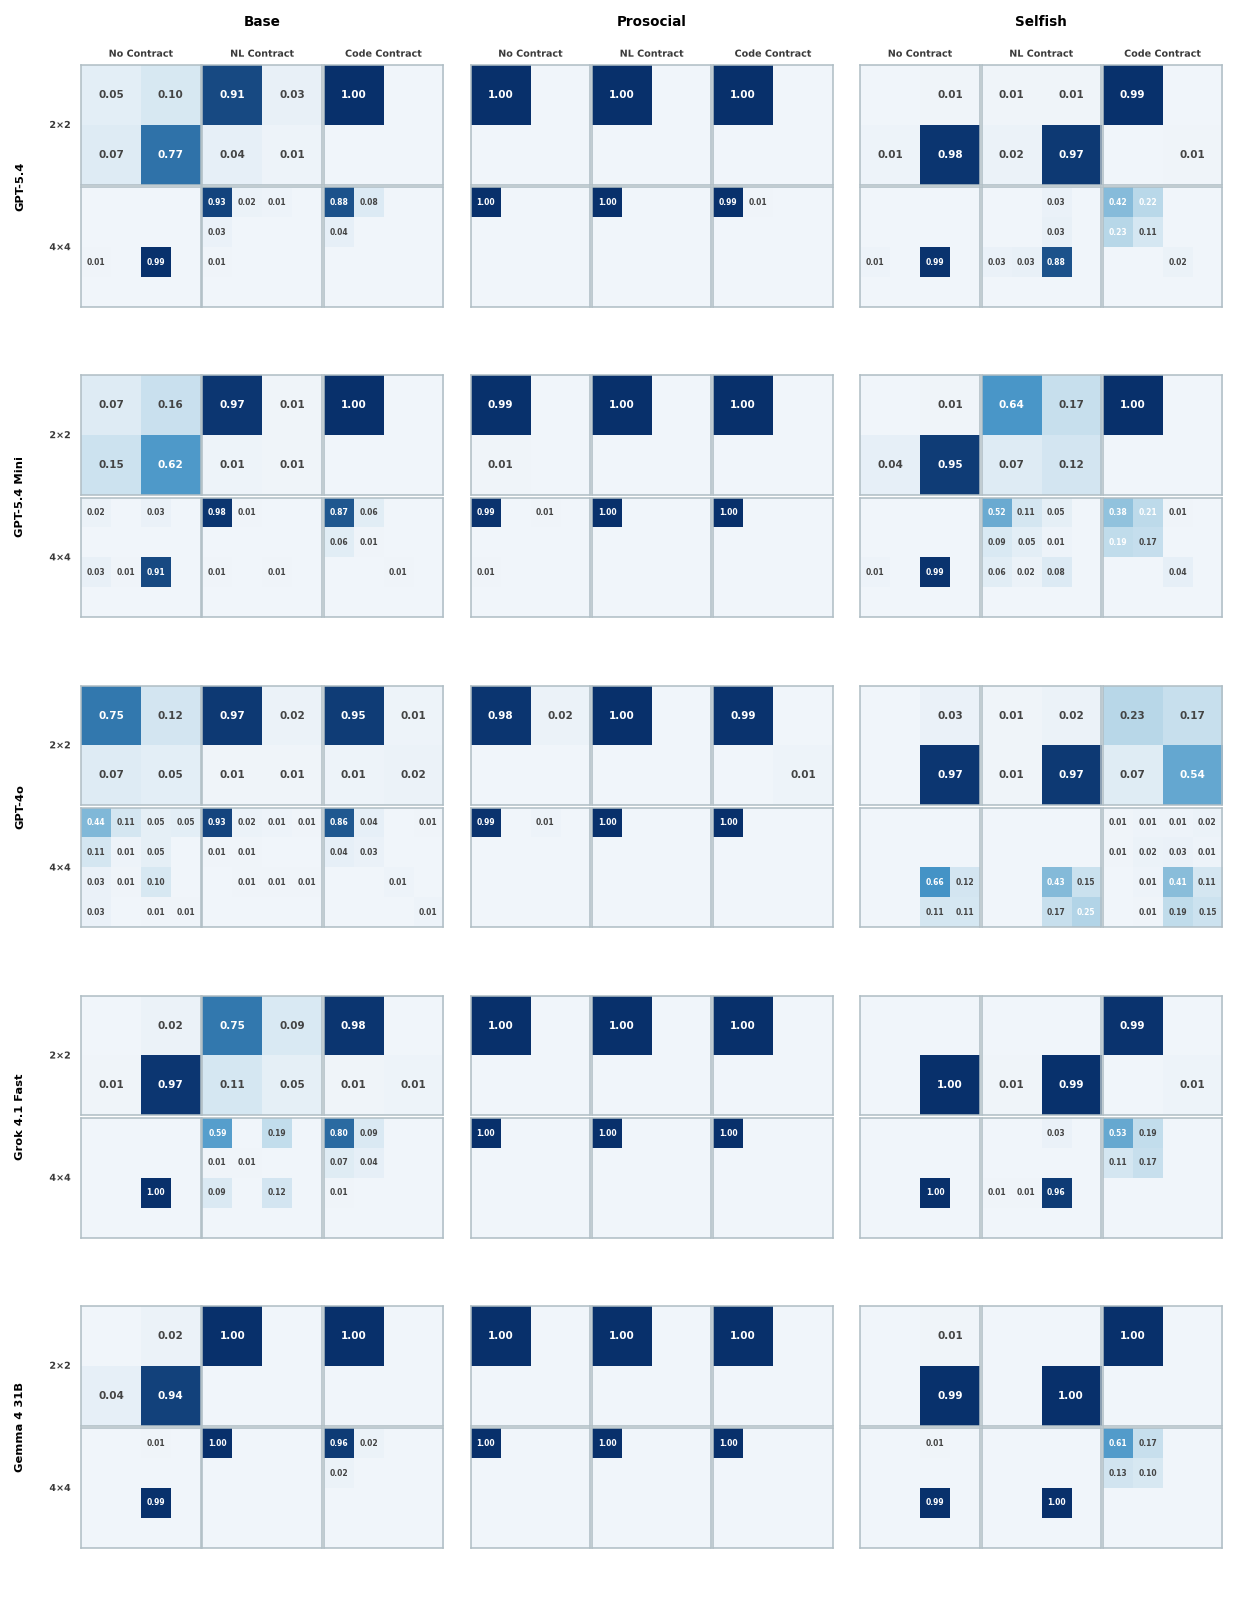

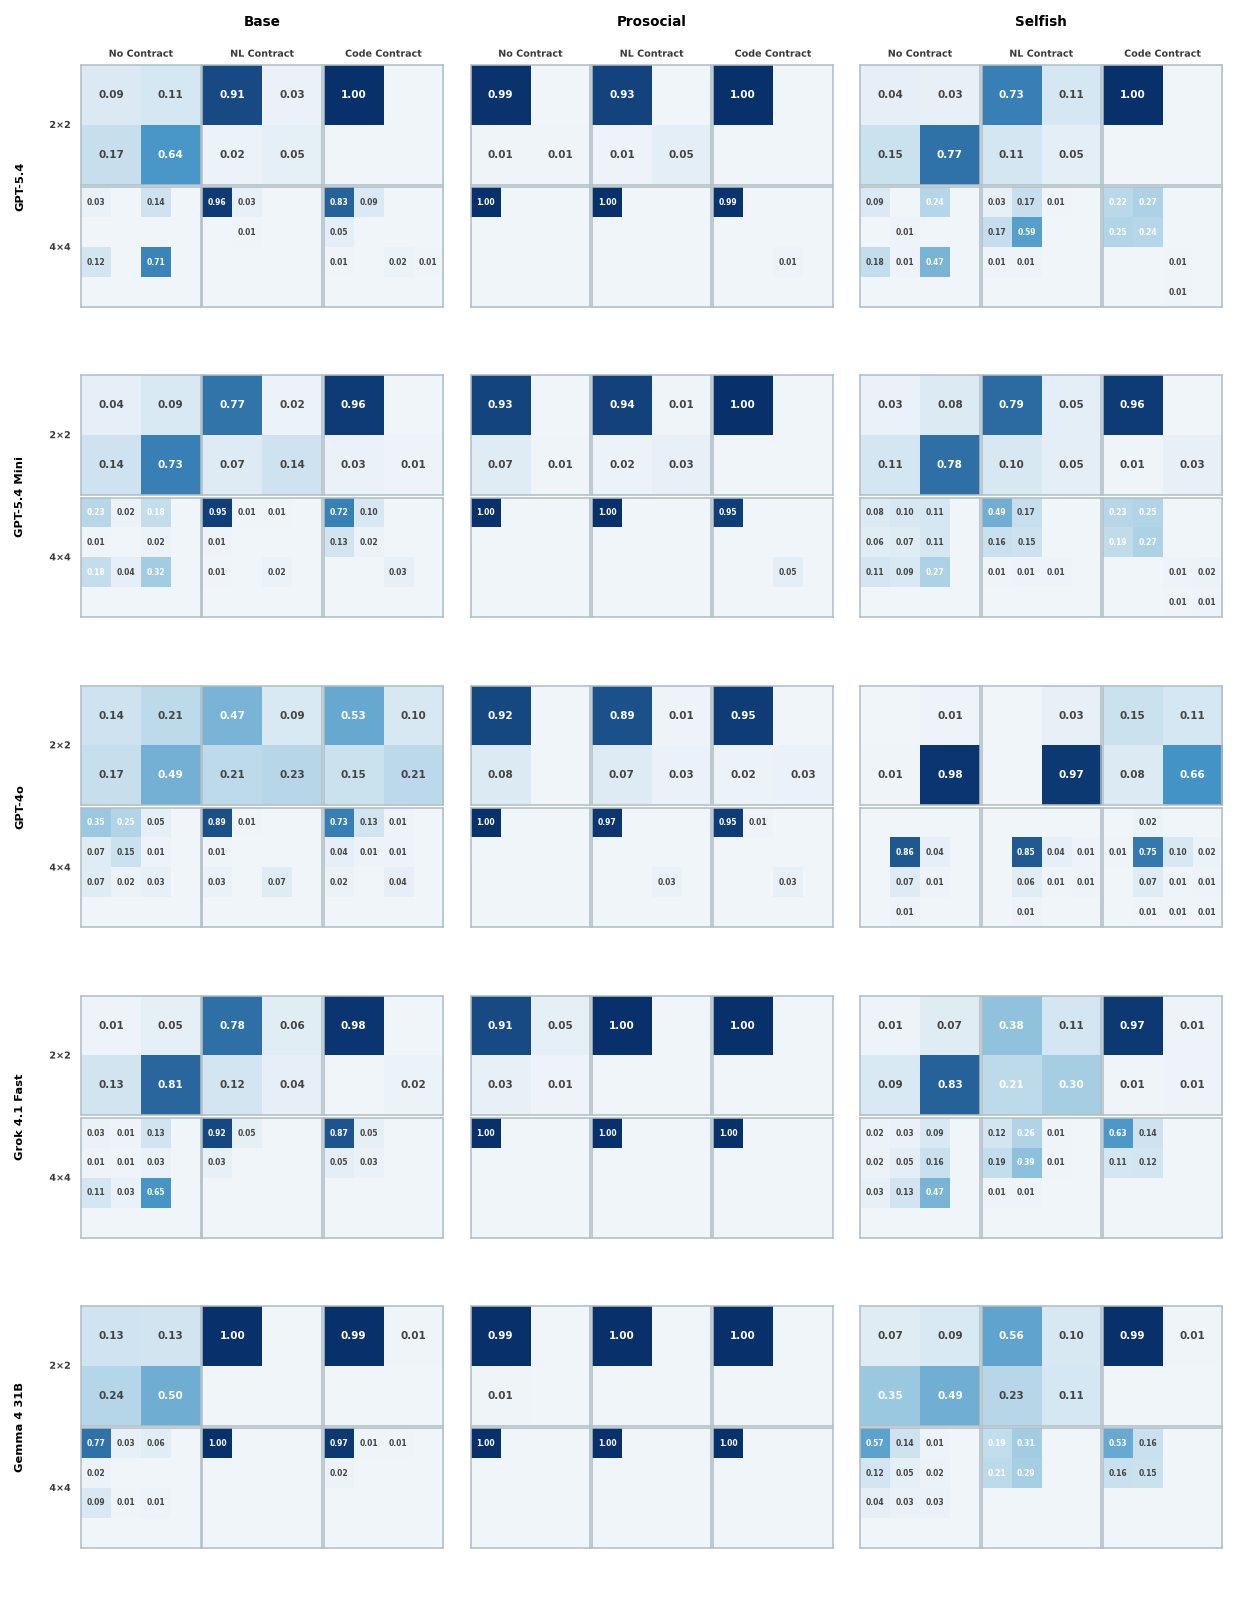

Saved all heatmaps


In [38]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe
import matplotlib.gridspec as gridspec

_MINI_HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    "mini_prop_blue",
    ["#f0f5fa", "#9ecae1", "#4292c6", "#08306b"],
)

HEATMAP_CONTRACT_ORDER = ["no_comm", "code_nl", "code_law"]
HEATMAP_PM_ORDER = ["base", "cooperative", "selfish"]
CONTRACT_DISPLAY = {
    "no_comm": "No Contract", "code_nl": "NL Contract", "code_law": "Code Contract",
}
PM_DISPLAY = {"base": "Base", "selfish": "Selfish", "cooperative": "Prosocial"}

_ANNOT_GRAY = "#444444"


def _draw_mini_heatmap(ax, matrix):
    """Draw a single heatmap cell: cell (i,j) = count_ij / sum(all counts)."""
    n = len(matrix)
    total = sum(float(matrix[i][j]) for i in range(n) for j in range(n))
    if total <= 0:
        prop = [[0.0] * n for _ in range(n)]
    else:
        prop = [[float(matrix[i][j]) / total for j in range(n)] for i in range(n)]

    max_p = max(max(r) for r in prop) if any(any(r) for r in prop) else 1.0

    ax.imshow(
        prop,
        cmap=_MINI_HEATMAP_CMAP,
        aspect="equal",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_box_aspect(1)
    ax.set_anchor("S" if n == 2 else "N")
    ax.grid(False)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(length=0)

    _annot_fs = 5 if n == 2 else 3.7
    for i in range(n):
        for j in range(n):
            p = prop[i][j]
            if p > 0:
                color = "white" if p > max_p * 0.5 else _ANNOT_GRAY
                ax.text(
                    j, i, f"{p:.2f}", ha="center", va="center",
                    color=color, fontsize=_annot_fs, fontweight="bold",
                )


def plot_combined_heatmaps(summary_df, game):
    """Combined heatmap figure: rows = model × dataset_size (2x2/4x4 alternating),
    cols = prompt_mode × contract_mode. US letter portrait (8.5 × 11 in)."""
    subset = summary_df[summary_df["game"] == game].copy()

    present = set(subset["model_display"].unique())
    models = [m for m in MODEL_ORDER_PREFERRED if m in present] + sorted(
        present - set(MODEL_ORDER_PREFERRED)
    )

    n_models = len(models)
    n_contract = len(HEATMAP_CONTRACT_ORDER)
    n_pm = len(HEATMAP_PM_ORDER)
    _pm_spacer_w = 0.20
    _wspace = 0.018
    _model_hspace = 0.0

    width_ratios = []
    for pm_i in range(n_pm):
        width_ratios.extend([1.0] * n_contract)
        if pm_i < n_pm - 1:
            width_ratios.append(_pm_spacer_w)
    n_cols = len(width_ratios)

    def _grid_col(pm_idx: int, cm_idx: int) -> int:
        return pm_idx * (n_contract + 1) + cm_idx

    fig = plt.figure(figsize=(8.5, 11.0))
    outer_gs = gridspec.GridSpec(
        n_models,
        1,
        figure=fig,
        height_ratios=[1.0] * n_models,
        hspace=_model_hspace,
    )

    axes = np.empty((n_models, 2, n_cols), dtype=object)

    for m_idx in range(n_models):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            2,
            n_cols,
            subplot_spec=outer_gs[m_idx, 0],
            wspace=_wspace,
            hspace=_wspace,
            height_ratios=[1, 1],
            width_ratios=width_ratios,
        )
        for ds in range(2):
            for c in range(n_cols):
                axes[m_idx, ds, c] = fig.add_subplot(inner_gs[ds, c])

    _hm_left, _hm_right = 0.085, 0.98
    fig.subplots_adjust(left=_hm_left, right=_hm_right, top=0.96, bottom=0.02)

    _pm_spacer_cols = [
        _grid_col(pm_idx, n_contract - 1) + 1 for pm_idx in range(n_pm - 1)
    ]
    for m_idx in range(n_models):
        for sc in _pm_spacer_cols:
            for ds in range(2):
                axes[m_idx, ds, sc].axis("off")

    for m_idx, model in enumerate(models):
        model_data = subset[subset["model_display"] == model]

        for ds_offset, ds in enumerate(["2x2", "4x4"]):
            n = 2 if ds == "2x2" else 4

            for pm_idx, pm in enumerate(HEATMAP_PM_ORDER):
                for cm_idx, cm in enumerate(HEATMAP_CONTRACT_ORDER):
                    col = _grid_col(pm_idx, cm_idx)
                    ax = axes[m_idx, ds_offset, col]

                    row = model_data[
                        (model_data["prompt_mode"] == pm)
                        & (model_data["contract_mode"] == cm)
                        & (model_data["dataset_size"] == ds)
                    ]

                    if row.empty:
                        ax.axis("off")
                        continue

                    jam_str = row["joint_action_matrix"].iloc[0]
                    if pd.isna(jam_str):
                        ax.axis("off")
                        continue

                    matrix = json.loads(jam_str)
                    while len(matrix) < n:
                        matrix.append([0] * n)
                    for i in range(n):
                        while len(matrix[i]) < n:
                            matrix[i].append(0)

                    _draw_mini_heatmap(ax, matrix)

    for pm_idx in range(len(HEATMAP_PM_ORDER)):
        for cm_idx, cm in enumerate(HEATMAP_CONTRACT_ORDER):
            col = _grid_col(pm_idx, cm_idx)
            pos = axes[0, 0, col].get_position()
            t_cm = fig.text(
                pos.x0 + pos.width / 2, pos.y1 + 0.004,
                CONTRACT_DISPLAY[cm], ha="center", va="bottom",
                fontsize=4.6, color="#3a3a3a", fontweight="bold",
            )
            t_cm.set_path_effects(
                [pe.withStroke(linewidth=2.2, foreground="white")]
            )

    for pm_idx, pm in enumerate(HEATMAP_PM_ORDER):
        c0 = _grid_col(pm_idx, 0)
        c1 = _grid_col(pm_idx, n_contract - 1)
        x0 = axes[0, 0, c0].get_position().x0
        x1 = axes[0, 0, c1].get_position().x0 + axes[0, 0, c1].get_position().width
        fig.text(
            (x0 + x1) / 2, axes[0, 0, 0].get_position().y1 + 0.022,
            PM_DISPLAY[pm], ha="center", va="bottom",
            fontsize=6.5, fontweight="bold",
        )

    for m_idx, model in enumerate(models):
        ax_top = axes[m_idx, 0, 0]
        ax_bot = axes[m_idx, 1, 0]
        p_top = ax_top.get_position()
        p_bot = ax_bot.get_position()
        x_heatmap_left = min(p_top.x0, p_bot.x0)
        x_ds = x_heatmap_left - 0.008
        x_model = x_heatmap_left - 0.048

        y_mid = (p_top.y1 + p_bot.y0) / 2
        fig.text(
            x_model, y_mid, model, ha="center", va="center",
            fontsize=5.5, fontweight="bold", rotation=90,
        )

        y_top_mid = (p_top.y0 + p_top.y1) / 2
        y_bot_mid = (p_bot.y0 + p_bot.y1) / 2
        for y_pos, label in ((y_top_mid, "2×2"), (y_bot_mid, "4×4")):
            t_ds = fig.text(
                x_ds, y_pos, label, ha="right", va="center",
                fontsize=4.6, color="#3a3a3a", fontweight="bold",
            )
            t_ds.set_path_effects(
                [pe.withStroke(linewidth=2.2, foreground="white")]
            )

    for m_idx in range(n_models):
        for ds in range(2):
            for c in range(n_cols):
                ax = axes[m_idx, ds, c]
                if not ax.images:
                    continue
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_color("#b0bec5")
                    spine.set_linewidth(0.75)

    return fig


# Generate one figure per game, US letter portrait
heatmap_dir = FIGURES_DIR / "heatmaps"
heatmap_dir.mkdir(parents=True, exist_ok=True)

for game in ("pd", "sh"):
    fig = plot_combined_heatmaps(summary_df, game)
    if fig is not None:
        fname = f"heatmap_{game}.png"
        fig.savefig(heatmap_dir / fname, dpi=300, bbox_inches="tight")
        plt.show()  # Only show the first plot inline

print("Saved all heatmaps")   


## 5. TableGames RQs

(Excludes $\lambda$ estimation; see later appendix.)


In [39]:
import sys

sys.path.insert(0, str(PROJECT_ROOT / "eval" / "analysis"))

from rq1_analysis import (
    bootstrap_realizability_differences,
    expand_to_sample_level,
    fit_realizability_glmm,
    generate_rq1_summary_table,
    test_irreducibility,
    test_structural_specificity,
)

from rq2_analysis import (
    generate_rq2_summary_table,
    test_persistence_4x4,
    test_substitutability_2x2,
    test_three_way_interaction,
)

RNG = np.random.default_rng(42)

In [40]:
sample_df = expand_to_sample_level(scenario_stats_df, rng=RNG)

cell_counts = (
    sample_df.groupby(["game", "dataset_size", "prompt_mode", "contract_mode"])
    .size()
    .reset_index(name="n_rows")
)
print(f"{len(sample_df)} pseudo-sample rows")
display(sample_df[["game", "dataset_size", "prompt_mode", "contract_mode", "util_correct"]].head(3))

900 pseudo-sample rows


,game,dataset_size,prompt_mode,contract_mode,util_correct
0,pd,4x4,base,no_comm,0
1,pd,4x4,base,no_comm,0
2,pd,4x4,base,no_comm,0


$\hat{\Delta} = 1 - \alpha_u$

In [41]:
irreducibility_results = []

for game in ["pd", "sh"]:
    gname = "PD" if game == "pd" else "Stag Hunt"

    for cond in [
        {
            "label": "selfish, 4×4, code-law",
            "dataset_size": "4x4",
            "prompt_mode": "selfish",
            "contract_mode": "code_law",
        },
        {
            "label": "selfish, 4×4, code-nl",
            "dataset_size": "4x4",
            "prompt_mode": "selfish",
            "contract_mode": "code_nl",
        },
        {
            "label": "base, 2×2, code-law",
            "dataset_size": "2x2",
            "prompt_mode": "base",
            "contract_mode": "code_law",
        },
    ]:
        result = test_irreducibility(
            sample_df,
            game=game,
            dataset_size=cond["dataset_size"],
            prompt_mode=cond["prompt_mode"],
            contract_mode=cond["contract_mode"],
            n_bootstrap=10000,
            seed=42,
        )
        irreducibility_results.append(
            {
                "game": gname,
                "condition": cond["label"],
                "Gamma_hat": result["point_estimate"],
                "CI95_lo": result["ci_lower"],
                "CI95_hi": result["ci_upper"],
                "p": result["p_value"],
                "n_scenarios": result["n_scenarios"],
            }
        )

irreducibility_df = pd.DataFrame(irreducibility_results)
display(irreducibility_df.round(4))

,game,condition,Gamma_hat,CI95_lo,CI95_hi,p,n_scenarios
0,PD,"selfish, 4×4, code-law",0.60,0.4667,0.7333,0.0000,5
1,PD,"selfish, 4×4, code-nl",0.88,0.8000,1.0000,0.0000,5
2,PD,"base, 2×2, code-law",0.00,0.0000,0.0000,1.0000,5
3,Stag Hunt,"selfish, 4×4, code-law",0.68,0.5333,0.8667,0.0000,5
4,Stag Hunt,"selfish, 4×4, code-nl",0.84,0.7333,0.9333,0.0000,5
5,Stag Hunt,"base, 2×2, code-law",0.08,0.0000,0.1333,0.3259,5


$\Delta = P(\mathrm{util} \mid \mathrm{coop}) - P(\mathrm{util} \mid \mathrm{selfish})$

In [42]:
realizability_results = []

for game in ["pd", "sh"]:
    gname = "PD" if game == "pd" else "Stag Hunt"
    game_df = sample_df[sample_df["game"] == game]

    for dataset_size in ["4x4", "2x2"]:
        glmm_result = fit_realizability_glmm(game_df, dataset_size)
        boot_result = bootstrap_realizability_differences(
            game_df, dataset_size, n_bootstrap=1000, seed=42
        )

        for regime_val in ["no_comm", "code_nl", "code_law"]:
            diff = glmm_result["differences"][regime_val]
            boot = boot_result[regime_val]
            realizability_results.append(
                {
                    "game": gname,
                    "variant": dataset_size,
                    "regime": regime_val,
                    "delta": diff,
                    "CI95_lo": boot["ci_lower"],
                    "CI95_hi": boot["ci_upper"],
                    "p": boot["p_value"],
                }
            )

realizability_df = pd.DataFrame(realizability_results)
display(realizability_df.round(4))

/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,game,variant,regime,delta,CI95_lo,CI95_hi,p
0,PD,4x4,no_comm,1.00,1.00,1.0,0.0000
1,PD,4x4,code_nl,0.88,0.70,1.0,0.0000
2,PD,4x4,code_law,0.60,0.40,0.8,0.0000
3,PD,2x2,no_comm,1.00,1.00,1.0,0.0000
4,PD,2x2,code_nl,0.88,0.70,1.0,0.0000
5,PD,2x2,code_law,0.16,0.00,0.4,0.3495
6,Stag Hunt,4x4,no_comm,0.88,0.70,1.0,0.0000
7,Stag Hunt,4x4,code_nl,0.84,0.70,1.0,0.0000
8,Stag Hunt,4x4,code_law,0.68,0.40,0.9,0.0000
9,Stag Hunt,2x2,no_comm,1.00,1.00,1.0,0.0000


$P(\mathrm{util} \mid 2 \times 2) - P(\mathrm{util} \mid 4 \times 4)$

In [43]:
specificity_results = []

for game in ["pd", "sh"]:
    gname = "PD" if game == "pd" else "Stag Hunt"
    game_df = sample_df[sample_df["game"] == game]

    result = test_structural_specificity(
        game_df,
        prompt_mode="selfish",
        contract_mode="code_law",
        n_bootstrap=10000,
        seed=42,
    )

    specificity_results.append(
        {
            "game": gname,
            "delta_2x2_minus_4x4": result["point_estimate"],
            "CI90_lo": result["ci_lower"],
            "p": result["p_value"],
            "n_scenarios": result["n_scenarios"],
        }
    )

specificity_df = pd.DataFrame(specificity_results)
display(specificity_df.round(4))

,game,delta_2x2_minus_4x4,CI90_lo,p,n_scenarios
0,PD,0.44,0.44,0.0,1
1,Stag Hunt,0.52,0.52,0.0,1


Holm–Bonferroni

In [44]:
summary_df = generate_rq1_summary_table(sample_df, n_bootstrap=10000, seed=42)

display_df = summary_df.copy()
display_df["estimate_str"] = display_df.apply(
    lambda r: (
        f"{r['estimate']:.4f} [{r['ci_lower']:.4f}, {r['ci_upper']:.4f}]"
        if r["ci_upper"] is not None
        else f"{r['estimate']:.4f} [{r['ci_lower']:.4f}, ∞]"
    ),
    axis=1,
)
display_df["sig"] = display_df["p_value"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
)

headline_tests = display_df[display_df["headline_test"]][
    ["test", "game", "cell", "estimate_str", "p_value", "sig", "corrected_significant"]
]
display(headline_tests)

RESULTS_DIR.mkdir(exist_ok=True)
summary_df.to_csv(RESULTS_DIR / "rq1_summary.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'rq1_summary.csv'}")

/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,test,game,cell,estimate_str,p_value,sig,corrected_significant
0,Irreducibility,pd,"(selfish, 4×4, code-law)","0.6000 [0.4667, 0.7333]",0.0,***,True
2,Irreducibility,sh,"(selfish, 4×4, code-law)","0.6800 [0.5333, 0.8667]",0.0,***,True
6,Realizability,pd,"4x4, code_law","0.6000 [0.4000, 0.8000]",0.0,***,True
12,Realizability,sh,"4x4, code_law","0.6800 [0.4000, 0.9000]",0.0,***,True
16,Structural specificity,pd,"(selfish, code-law)","0.4400 [0.4400, nan]",0.0,***,True
17,Structural specificity,sh,"(selfish, code-law)","0.5200 [0.5200, nan]",0.0,***,True


Wrote /home/anonymous/code/research/gt-harmbench/results/rq1_summary.csv


In [45]:
cell_counts = (
    sample_df[sample_df["prompt_mode"].isin(["selfish", "cooperative"])]
    .groupby(["game", "dataset_size", "prompt_mode", "contract_mode"])
    .size()
    .reset_index(name="n_rows")
)
display(cell_counts)

,game,dataset_size,prompt_mode,contract_mode,n_rows
0,pd,2x2,cooperative,code_law,25
1,pd,2x2,cooperative,code_nl,25
2,pd,2x2,cooperative,no_comm,25
3,pd,2x2,selfish,code_law,25
4,pd,2x2,selfish,code_nl,25
5,pd,2x2,selfish,no_comm,25
6,pd,4x4,cooperative,code_law,25
7,pd,4x4,cooperative,code_nl,25
8,pd,4x4,cooperative,no_comm,25
9,pd,4x4,selfish,code_law,25


Substitution (2×2)

In [46]:
substitutability_rows = []

for game in ["pd", "sh"]:
    gname = "PD" if game == "pd" else "Stag Hunt"
    result = test_substitutability_2x2(sample_df, game=game, n_bootstrap=10000, seed=42)
    substitutability_rows.append(
        {
            "game": gname,
            "LR_p_interaction": result["interaction_p"],
            "delta_no_comm": result["contrast_no_comm"],
            "delta_code_law": result["contrast_code_law"],
            "delta_no_minus_cl": result["contrast_diff"],
            "CI95_lo": result["ci_lower"],
            "CI95_hi": result["ci_upper"],
            "P_util_selfish_code_law": result["selfish_code_law_acc"],
            "ceiling": result["has_ceiling_effect"],
        }
    )

substitutability_df = pd.DataFrame(substitutability_rows)
display(substitutability_df.round(4))

/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,game,LR_p_interaction,delta_no_comm,delta_code_law,delta_no_minus_cl,CI95_lo,CI95_hi,P_util_selfish_code_law,ceiling
0,PD,0.0,1.0,0.16,0.84,0.6,1.0,0.84,False
1,Stag Hunt,0.0,1.0,0.16,0.84,0.6,1.0,0.84,False


Persistence (4×4)

In [47]:
persistence_rows = []

for game in ["pd", "sh"]:
    gname = "PD" if game == "pd" else "Stag Hunt"
    result = test_persistence_4x4(sample_df, game=game, n_bootstrap=10000, seed=42)

    for regime_val in ["no_comm", "code_nl", "code_law"]:
        persistence_rows.append(
            {
                "game": gname,
                "regime": regime_val,
                "delta": result["delta_by_regime"][regime_val]["delta"],
                "CI95_lo": result[f"ci_lower_{regime_val}"],
                "CI95_hi": result[f"ci_upper_{regime_val}"],
                "p": result[f"p_{regime_val}"],
            }
        )

    persistence_rows.append(
        {
            "game": gname,
            "regime": "invariance (Δ_nc − Δ_cl)",
            "delta": result["invariance_contrast"],
            "CI95_lo": result["invariance_ci_lower"],
            "CI95_hi": result["invariance_ci_upper"],
            "p": np.nan,
        }
    )

persistence_df = pd.DataFrame(persistence_rows)
display(persistence_df.round(4))

,game,regime,delta,CI95_lo,CI95_hi,p
0,PD,no_comm,1.00,1.0,1.0,0.0
1,PD,code_nl,0.88,0.7,1.0,0.0
2,PD,code_law,0.60,0.4,0.8,0.0
3,PD,invariance (Δ_nc − Δ_cl),0.40,0.4,0.4,NaN
4,Stag Hunt,no_comm,0.88,0.7,1.0,0.0
5,Stag Hunt,code_nl,0.84,0.7,1.0,0.0
6,Stag Hunt,code_law,0.68,0.4,0.9,0.0
7,Stag Hunt,invariance (Δ_nc − Δ_cl),0.20,0.2,0.2,NaN


Pooled across regimes

In [48]:
def _bootstrap_delta_pooled(
    df: pd.DataFrame,
    game: str,
    n_bootstrap: int = 20000,
    seed: int = 42,
) -> dict:
    sub = df[(df["game"] == game) & (df["prompt_mode"].isin(["selfish", "cooperative"]))].copy()
    if sub.empty:
        return {
            "game": game,
            "delta": np.nan,
            "CI95_lo": np.nan,
            "CI95_hi": np.nan,
            "p": np.nan,
            "n": 0,
        }

    cluster_cols = [c for c in ["scenario_id", "scenario", "sample_id"] if c in sub.columns]
    if "model_display" in sub.columns:
        cluster_cols = ["model_display"] + cluster_cols

    rng = np.random.default_rng(seed)

    def delta_for(d: pd.DataFrame) -> float:
        p_coop = d.loc[d["prompt_mode"] == "cooperative", "util_correct"].mean()
        p_self = d.loc[d["prompt_mode"] == "selfish", "util_correct"].mean()
        return float(p_coop - p_self)

    point = delta_for(sub)

    if cluster_cols:
        clusters = sub[cluster_cols].astype(str).agg("|".join, axis=1)
        sub = sub.assign(_cluster_id=clusters)
        unique = sub["_cluster_id"].unique()

        boots = []
        for _ in range(n_bootstrap):
            sampled = rng.choice(unique, size=len(unique), replace=True)
            boot = sub[sub["_cluster_id"].isin(sampled)]
            boots.append(delta_for(boot))
        boots = np.asarray(boots)
    else:
        boots = np.asarray(
            [
                delta_for(
                    sub.sample(
                        frac=1.0,
                        replace=True,
                        random_state=int(rng.integers(1 << 31)),
                    )
                )
                for _ in range(n_bootstrap)
            ]
        )

    lo, hi = np.quantile(boots, [0.025, 0.975])
    p = 2 * min((boots <= 0).mean(), (boots >= 0).mean())

    return {
        "game": ("PD" if game == "pd" else "Stag Hunt"),
        "delta": point,
        "CI95_lo": float(lo),
        "CI95_hi": float(hi),
        "p": float(p),
        "n": int(len(sub)),
    }


pooled_rows = [_bootstrap_delta_pooled(sample_df, g) for g in ["pd", "sh"]]
pooled_df = pd.DataFrame(pooled_rows)
display(pooled_df.round(4))


,game,delta,CI95_lo,CI95_hi,p,n
0,PD,0.7533,0.6556,0.8588,0.0,300
1,Stag Hunt,0.6667,0.5650,0.7709,0.0,300


Three-way interaction

In [49]:
three_way_headlines = []
marginal_rows = []

for game in ["pd", "sh"]:
    gname = "PD" if game == "pd" else "Stag Hunt"
    result = test_three_way_interaction(sample_df, game=game, n_bootstrap=10000, seed=42)

    three_way_headlines.append(
        {
            "game": gname,
            "LR_p_three_way": result["three_way_p"],
            "regime_slope_2x2": result["contrast_2x2"],
            "regime_slope_4x4": result["contrast_4x4"],
            "three_way_contrast": result["three_way_contrast"],
            "CI95_lo": result["ci_lower"],
            "CI95_hi": result["ci_upper"],
            "p_boot": result["p_value"],
        }
    )

    for variant_val in ["2x2", "4x4"]:
        for regime_val in ["no_comm", "code_nl", "code_law"]:
            marginal_rows.append(
                {
                    "game": gname,
                    "variant": variant_val,
                    "regime": regime_val,
                    "delta": result["marginal_effects"][variant_val][regime_val]["delta"],
                }
            )

three_way_df = pd.DataFrame(three_way_headlines)
display(three_way_df.round(4))

marginal_df = pd.DataFrame(marginal_rows)
if not marginal_df.empty:
    display(
        marginal_df.pivot_table(
            index=["game", "variant"], columns="regime", values="delta"
        ).round(4)
    )

/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/anonymous/miniconda3/envs/contracts/lib/python3.13

,game,LR_p_three_way,regime_slope_2x2,regime_slope_4x4,three_way_contrast,CI95_lo,CI95_hi,p_boot
0,PD,0.0002,0.84,0.4,0.44,-0.15,0.8000,0.0363
1,Stag Hunt,0.0000,0.84,0.2,0.64,0.00,1.0801,0.0252


regime             code_law  code_nl  no_comm
game      variant                            
PD        2x2          0.16     0.88     1.00
          4x4          0.60     0.88     1.00
Stag Hunt 2x2          0.16     0.44     1.00
          4x4          0.68     0.84     0.88

Holm–Bonferroni

In [50]:
summary_df = generate_rq2_summary_table(sample_df, n_bootstrap=10000, seed=42)

display_df = summary_df.copy()
display_df["estimate_str"] = display_df.apply(
    lambda r: (
        f"{r['estimate']:.4f} [{r['ci_lower']:.4f}, {r['ci_upper']:.4f}]"
        if pd.notna(r["ci_lower"]) and pd.notna(r["ci_upper"])
        else f"{r['estimate']:.4f}"
    ),
    axis=1,
)
display_df["sig"] = display_df["p_value"].apply(
    lambda p: "***"
    if pd.notna(p) and p < 0.001
    else "**"
    if pd.notna(p) and p < 0.01
    else "*"
    if pd.notna(p) and p < 0.05
    else ""
)

headline_tests = display_df[display_df["headline_test"]][
    [
        "test",
        "game",
        "variant",
        "estimate_str",
        "p_value",
        "sig",
        "corrected_significant",
        "note",
    ]
]
display(headline_tests)

RESULTS_DIR.mkdir(exist_ok=True)
summary_df.to_csv(RESULTS_DIR / "rq2_summary.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'rq2_summary.csv'}")

/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/anonymous/miniconda3/envs/c

,test,game,variant,estimate_str,p_value,sig,corrected_significant,note
6,Persistence,pd,4x4,"0.6000 [0.4000, 0.8000]",0.0000,***,True,
9,Persistence,sh,4x4,"0.6800 [0.4000, 0.9000]",0.0000,***,True,
12,Three-way interaction,pd,both,"0.4400 [-0.1500, 0.8000]",0.0363,*,False,LRT p=1.8028e-04
13,Three-way interaction,sh,both,"0.6400 [0.0000, 1.0801]",0.0252,*,False,LRT p=3.1116e-05


Wrote /home/anonymous/code/research/gt-harmbench/results/rq2_summary.csv


Per-model contrasts

In [51]:
per_model_results = []

for model in sorted(sample_df["model_display"].unique()):
    model_df = sample_df[sample_df["model_display"] == model]
    for game in ["pd", "sh"]:
        gname = "PD" if game == "pd" else "Stag Hunt"
        try:
            result = test_three_way_interaction(
                model_df, game=game, n_bootstrap=5000, seed=42
            )
            per_model_results.append(
                {
                    "model": model,
                    "game": gname,
                    "three_way": result["three_way_contrast"],
                    "p": result["p_value"],
                    "slope_2x2": result["contrast_2x2"],
                    "slope_4x4": result["contrast_4x4"],
                }
            )
        except Exception as e:
            print(f"{model} / {gname}: {e}")

per_model_df = pd.DataFrame(per_model_results)
if not per_model_df.empty:
    display(per_model_df.pivot(index="model", columns="game", values="three_way").round(4))
    display(per_model_df[["model", "game", "p", "slope_2x2", "slope_4x4"]].round(4))

per_model_df.to_csv(RESULTS_DIR / "rq2_per_model.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'rq2_per_model.csv'}")

/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/anonymous/miniconda3/envs/contracts/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWar

game,PD,Stag Hunt
model,,
GPT-4o,0.2,0.2
GPT-5.4,0.6,0.8
GPT-5.4 Mini,0.6,0.8
Gemma 4 31B,0.4,1.0
Grok 4.1 Fast,0.4,0.4


,model,game,p,slope_2x2,slope_4x4
0,GPT-4o,PD,0.5282,0.2,0.0
1,GPT-4o,Stag Hunt,0.5282,0.2,0.0
2,GPT-5.4,PD,0.5282,1.0,0.4
3,GPT-5.4,Stag Hunt,0.5282,1.0,0.2
4,GPT-5.4 Mini,PD,0.5282,1.0,0.4
5,GPT-5.4 Mini,Stag Hunt,0.5282,1.0,0.2
6,Gemma 4 31B,PD,0.5282,1.0,0.6
7,Gemma 4 31B,Stag Hunt,0.4328,1.0,0.0
8,Grok 4.1 Fast,PD,0.5282,1.0,0.6
9,Grok 4.1 Fast,Stag Hunt,0.5282,1.0,0.6


Wrote /home/anonymous/code/research/gt-harmbench/results/rq2_per_model.csv


In [52]:
per_model_rows = []

for model in sorted(sample_df["model_display"].unique()):
    model_df = sample_df[sample_df["model_display"] == model]
    for game in ["pd", "sh"]:
        gname = "PD" if game == "pd" else "Stag Hunt"
        result = test_irreducibility(
            model_df,
            game=game,
            dataset_size="4x4",
            prompt_mode="selfish",
            contract_mode="code_law",
            n_bootstrap=5000,
            seed=42,
        )
        per_model_rows.append(
            {
                "model": model,
                "game": gname,
                "Gamma_hat": result["point_estimate"],
                "p": result["p_value"],
            }
        )

per_model_df = pd.DataFrame(per_model_rows)
if not per_model_df.empty:
    display(per_model_df.pivot(index="model", columns="game", values="Gamma_hat").round(4))

per_model_df.to_csv(RESULTS_DIR / "rq1_per_model.csv", index=False)
print(f"Wrote {RESULTS_DIR / 'rq1_per_model.csv'}")


game,PD,Stag Hunt
model,,
GPT-4o,1.0,1.0
GPT-5.4,0.6,0.8
GPT-5.4 Mini,0.6,0.8
Gemma 4 31B,0.4,0.4
Grok 4.1 Fast,0.4,0.4


Wrote /home/anonymous/code/research/gt-harmbench/results/rq1_per_model.csv


## 6. Code Contracts Primitives

9000 rows | pooled enforcement activated 8.5% → compliance 91.5%
saved: /home/anonymous/code/research/gt-harmbench/results/figures/contracting_code_law_primitives_in_generated_code.png


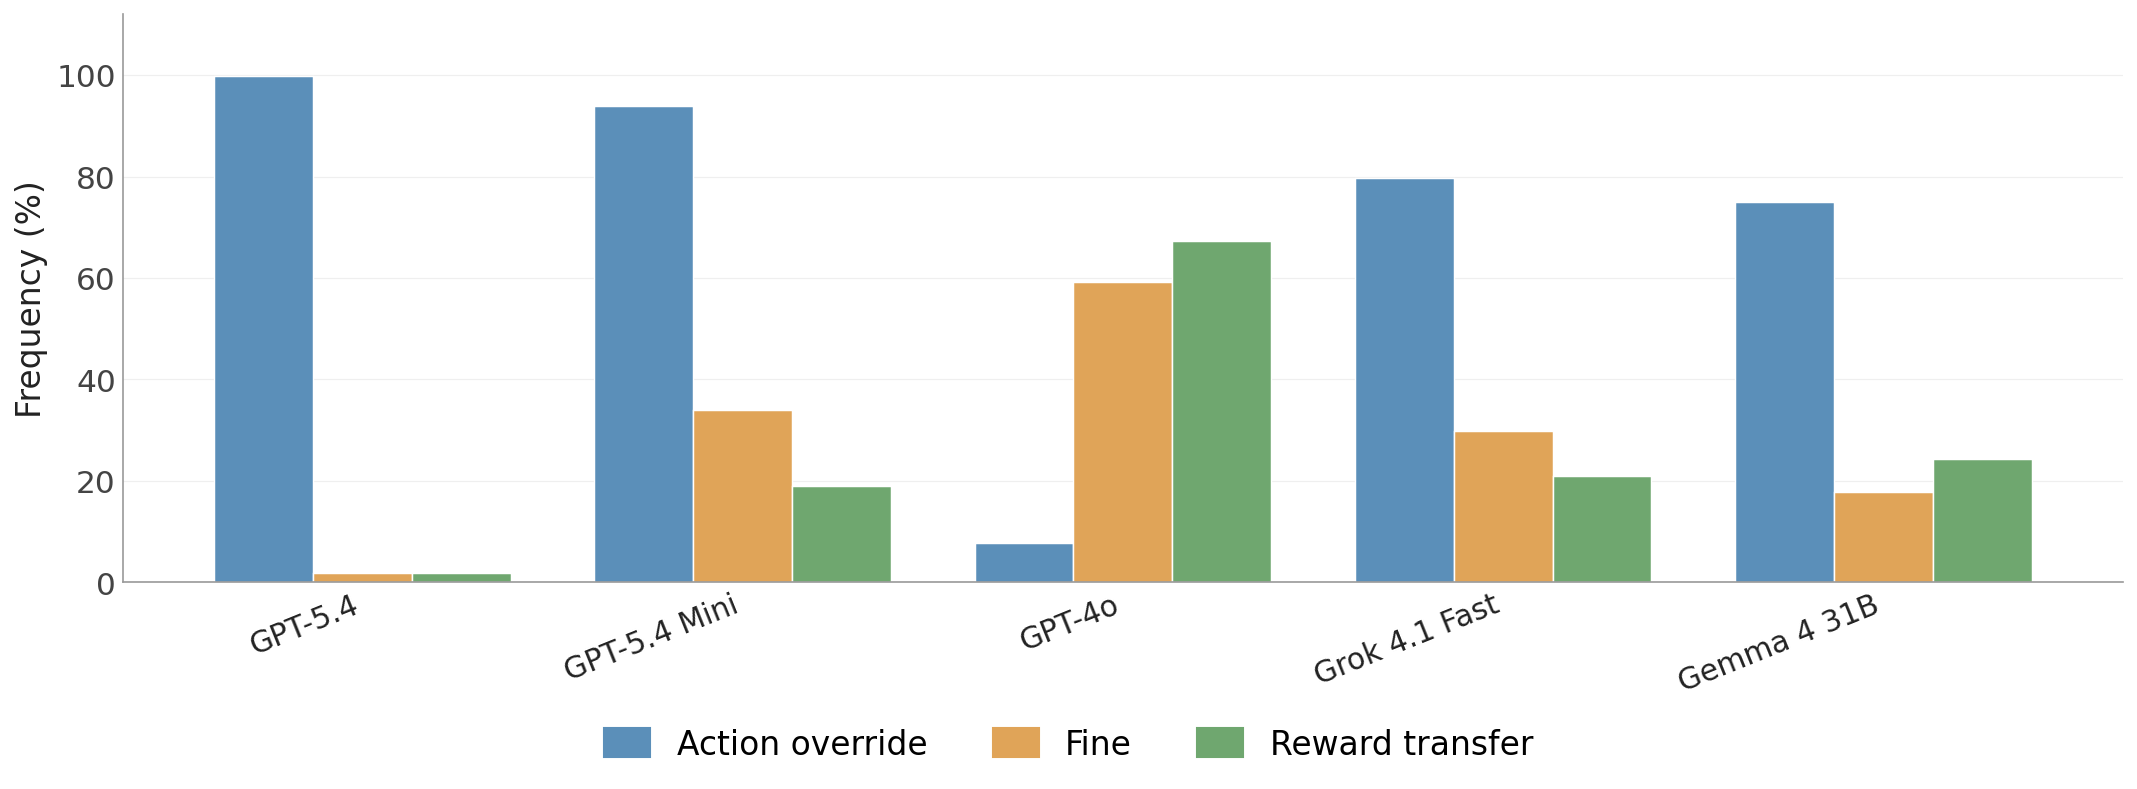

saved: /home/anonymous/code/research/gt-harmbench/results/figures/contracting_code_law_compliance_by_model.png


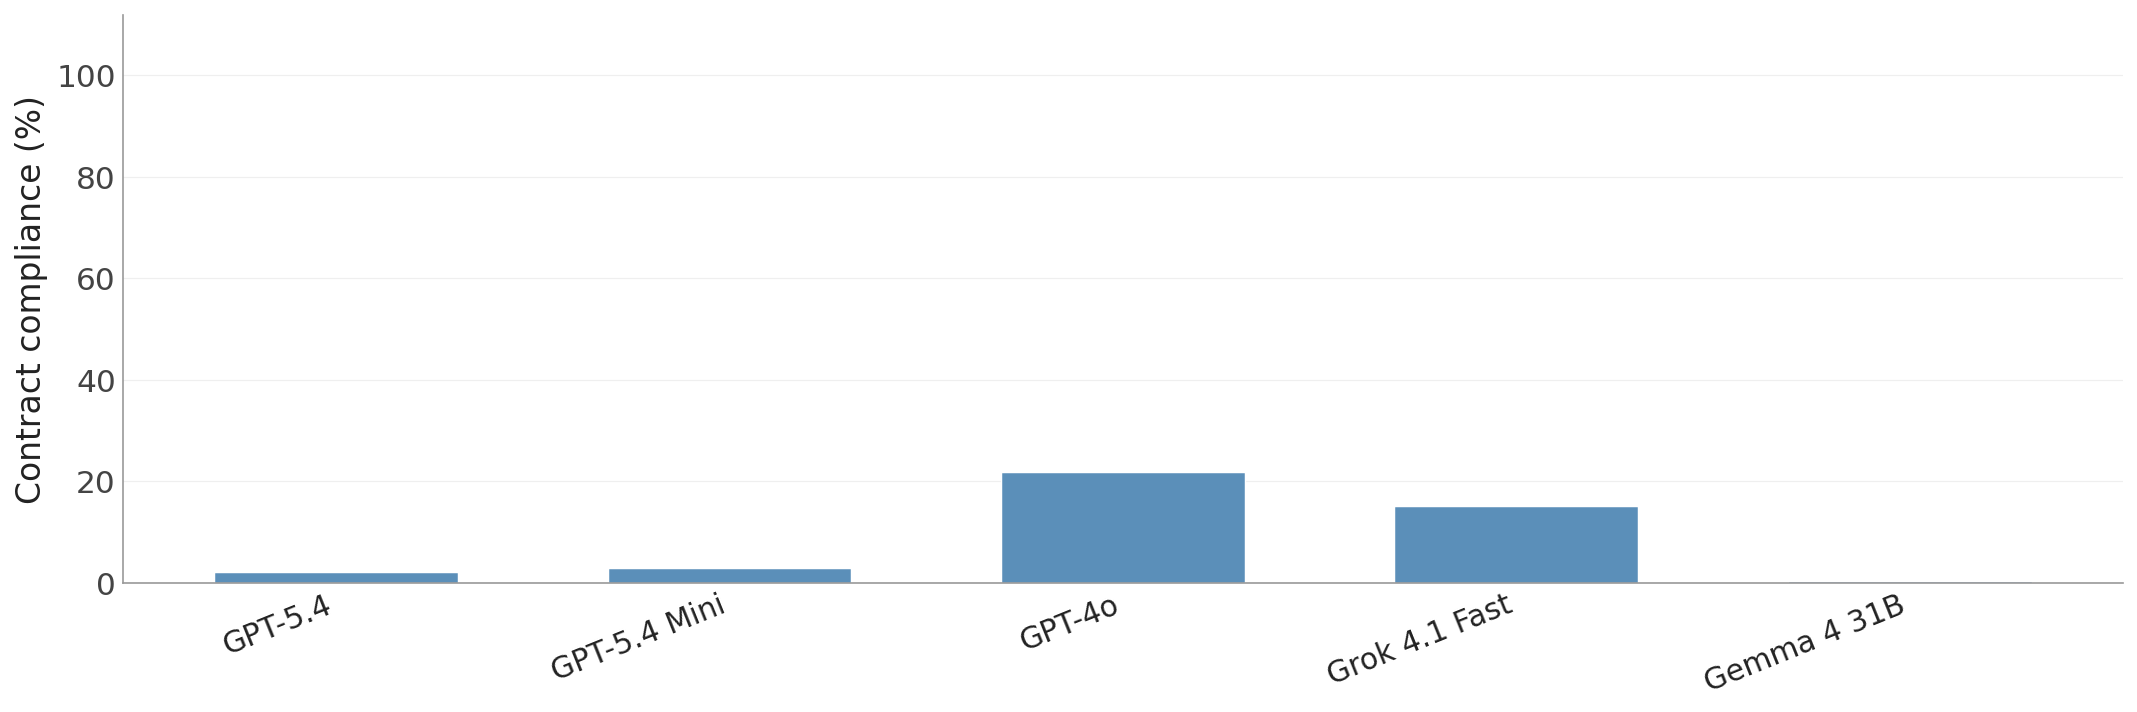

In [58]:
# see eval/analysis/code_law_primitives.py
import importlib
import sys

from eval.analysis.code_law_primitives import (
    aggregate_compliance_by_model,
    aggregate_primitives_in_generated_code_pooled,
    load_code_law_metric_samples,
    plot_contract_compliance_by_model,
    plot_primitives_in_generated_code_by_model,
)

metric_samples = load_code_law_metric_samples(
    batch_runs,
    prompt_modes=PROMPT_MODES,
    experiment_subdirs=("2x2-code-law", "4x4-code-law"),
    games=("pd", "sh"),
    verbose=False,
)
rates_code = aggregate_primitives_in_generated_code_pooled(metric_samples)
compliance_by_model = aggregate_compliance_by_model(metric_samples)

if metric_samples.empty:
    print("No code-law samples found (expected under <eval-dir>/<pm>/2x2-code-law|4x4-code-law/*.eval).")
else:
    act = float(metric_samples["enforcement_activated"].mean())
    print(
        f"{len(metric_samples)} rows | pooled enforcement activated {act:.1%} → "
        f"compliance {1.0 - act:.1%}"
    )
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

    fig_a = plot_primitives_in_generated_code_by_model(rates_code)
    out_a = FIGURES_DIR / "contracting_code_law_primitives_in_generated_code.png"
    fig_a.savefig(out_a, dpi=220, bbox_inches="tight", facecolor="white")
    print("saved:", out_a)
    plt.show()
    plt.close(fig_a)

    fig_b = plot_contract_compliance_by_model(compliance_by_model)
    out_b = FIGURES_DIR / "contracting_code_law_compliance_by_model.png"
    fig_b.savefig(out_b, dpi=220, bbox_inches="tight", facecolor="white")
    print("saved:", out_b)
    plt.show()
    plt.close(fig_b)
